# **ShapeUp Spatial to LMD Demo**

This notebook demonstrates how to transform HALO digital pathology annotations into XML files compatible with Laser Microdissection (LMD) systems.
It covers annotation parsing, LMD shape generation, spatial segmentation, visualization, and final XML export.

## Setup

Before running the notebook, please create the following directory structure:

- `ShapeUpLMD_demo.ipynb`
- `halo_shape_functions.py`
- `data/`
  - `wsi_analysis_demo.svs`
  - `wsi_analysis_demo.annotations`
  - `wsi_unbiased_analysis_demo.svs`
  - `wsi_unbiased_analysis_demo.annotations`
- `XML_files/` (auto-created)
- `unbiased_XML_files/` (auto-created)


### Set workbook directory as working directory

In [ ]:


from pathlib import Path
import ipynbname

# Get real notebook location
try:
    notebook_dir = Path(ipynbname.path()).parent.resolve()
except:
    notebook_dir = Path.cwd().resolve()

import sys
sys.path.append(str(notebook_dir))

## Enter Input Parameters
Please specify the number of clusters and the total area (in mm²) for the tumor analysis below.

- `num_clusters`: Number of clusters to generate.
- `area_mm2`: Area size in square millimeters.

In [2]:
# User parameters
num_clusters = 6
area_mm2 = 5

# Base folder (data lives inside the notebook directory)
base_path = notebook_dir / "data"

image_location = base_path / "wsi_analysis_demo.svs"
annotation_file = base_path / "wsi_analysis_demo.annotations"

# Output folders
xml_dir = notebook_dir / "XML_files"
unbiased_xml_dir = notebook_dir / "unbiased_XML_files"

xml_dir.mkdir(exist_ok=True)
unbiased_xml_dir.mkdir(exist_ok=True)


Import the helper functions WSI reader and path utilities needed for the workflow

In [ ]:

import halo_shape_functions as hsf
from tiatoolbox.wsicore import WSIReader
from pathlib import Path

## Load Whole-Slide Image and Parse Annotation Layers

In [16]:
# Define annotation layers
tumor_layer = 'tumor'
tissue_layer = 'tissue'
calibration_layer = 'calib'

# Parse layers into MultiPolygons
tumor_poly = hsf.parse_annotation_file(tumor_layer, annotation_file)
tissue_poly = hsf.parse_annotation_file(tissue_layer, annotation_file)
calib_layer = hsf.parse_annotation_file(calibration_layer, annotation_file)

#Bounding box rectangle around all polygons for image polygon overlays
outer_geom = tissue_poly.envelope


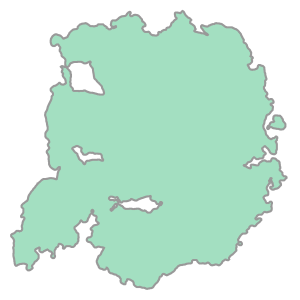

In [ ]:
#Display tissue mask
tissue_poly

In [ ]:
#Display tumor mask
tumor_poly

## Generate LMD-Compatible Shapes

`make_shapes_lmdable_xml` breaks multipolygon regions into smaller shapes suitable for LMD.


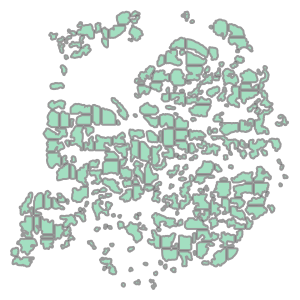

In [7]:
lmdable_shapes = hsf.make_shapes_lmdable_xml(
    image_location=image_location,
    collection_regions=tumor_poly,
    verbose=False,
    minimum_micrometers_between_shapes=60,
    minimum_micrometers_squared=100*100,
    maximum_micrometers_squared=600*600,
    n_slices_to_check=7
)

lmdable_shapes


In [ ]:
# Plot LMD-able shapes onto tissue
ret = hsf.plot_shapes_onto_tissue(
    shapes=lmdable_shapes,
    image_location=image_location,
    new_mpp=10,
    framing_shape=tissue_poly
)


## Segment Tumor into Spatial Clusters

`spatial_segmentation_brute_force` divides the tissue into clusters of approximately equal area.


In [ ]:
wsi_image = WSIReader.open(image_location)
mpp = wsi_image.info.as_dict()['mpp'][0]  # assume square pixels

spatial_sections = hsf.spatial_segmentation_brute_force(
    multipolygon=lmdable_shapes,
    tissue=tissue_poly.geoms[1],
    n=num_clusters,
    s=area_mm2,
    mpp=mpp
)

spatial_sections


### Overlay tumor spatial map on cropped WSI

In [ ]:
plot_return = hsf.plot_shapes_onto_tissue(spatial_sections, image_location, framing_shape=outer_geom)

In [10]:
# Output XML files for each spatial section
for section_number, section in spatial_sections.items():
    hsf.create_scope_xml2(
        xml_multipolygon=section,
        calib_layer=calib_layer,
        xml_file_name=Path(notebook_dir / 'XML_files') / f"section-{section_number}_test.xml",
        verbose=False
    )


## Unbiased Whole-Tissue Workflow



### Load Whole-Slide Image and Parse Annotation Layers

In [11]:
# Example paths for unbiased analysis
unb_image_location = base_path / "wsi_unbiased_analysis_demo.svs"
unb_annotation_file = base_path / "wsi_unbiased_analysis_demo.annotations"

# Parse tissue and calibration layers
unb_tissue_poly = hsf.parse_annotation_file('tissue', unb_annotation_file)
unb_calib_layer = hsf.parse_annotation_file('calib', unb_annotation_file)

unb_outer_geom = unb_tissue_poly.envelope

### Generate LMD-Compatible Shapes

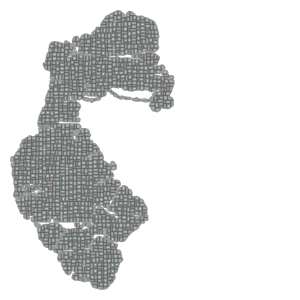

In [12]:
# Generate LMD-able shapes for whole tissue
lmdable_shapes_whole_tissue = hsf.make_shapes_lmdable_xml(
    image_location=unb_image_location,
    collection_regions=unb_tissue_poly,
    verbose=False,
    minimum_micrometers_between_shapes=50,
    minimum_micrometers_squared=100*100,
    maximum_micrometers_squared=250*250,
    n_slices_to_check=5
)

lmdable_shapes_whole_tissue

### Segment Whole Tissue into Spatial Clusters

Modify the number of clusters to be assigned to the tissue.

- `cluster_count`: Number of clusters to generate.

In [13]:
# Divide into clusters and output XML
Whole_tissue_spatial = hsf.rebalance_multipolygons_by_area(
    multipolygon=lmdable_shapes_whole_tissue,
    cluster_count=96
)

### Overlay whole tissue spatial map on cropped WSI

In [ ]:
# Generate spatial map

hsf.plot_multipolygons_on_wsi(multipolygon_dict = Whole_tissue_spatial, tissue_shape = unb_outer_geom, wsi_path= unb_image_location, cwd = notebook_dir )

### Generates XML files for the Whole tissue Spatial clusters.

In [15]:
hsf.partition_collections_to_xml(
    MultiPolygon_Dict=Whole_tissue_spatial, 
    chunk_size=14,
    rows=2,
    columns=7,
    calib=unb_calib_layer,
    cwd = notebook_dir
)
